# STUDI KASUS FORECASTING DATA MINING - PENJUALAN RETAIL
## Peramalan Jumlah Produk Terjual (Units Sold) pada Data Retail Store Inventory Menggunakan Linear Regression
### Framework: CRISP-DM (Cross-Industry Standard Process for Data Mining)

## Fase 1: Business Understanding

### A. Latar Belakang Masalah

Bisnis retail memiliki aktivitas penjualan dan pengelolaan stok barang setiap hari. Salah satu masalah yang sering terjadi adalah jumlah stok tidak sesuai dengan kebutuhan penjualan. Jika stok terlalu sedikit, toko bisa mengalami kehabisan barang. Sebaliknya, jika stok terlalu banyak, barang dapat menumpuk dan menambah biaya penyimpanan.

Dataset **retail_store_inventory.csv** berisi data penjualan dan persediaan produk retail, seperti tanggal, toko, produk, kategori, wilayah, jumlah stok, jumlah barang terjual, harga, diskon, promosi, cuaca, dan musim. Data tersebut dapat digunakan untuk menganalisis faktor-faktor yang memengaruhi jumlah penjualan produk.

Dalam project ini, forecasting dilakukan untuk memprediksi **Units Sold** atau jumlah unit produk yang terjual menggunakan metode **Linear Regression**. Model ini digunakan untuk melihat hubungan antara variabel target dengan faktor pendukung seperti stok barang, harga, diskon, promosi, cuaca, musim, wilayah, dan kategori produk. Hasil peramalan ini dapat membantu pihak retail dalam menentukan kebutuhan stok barang dan strategi penjualan.

### B. Permasalahan yang Diselesaikan

Permasalahan utama dalam project ini adalah toko retail perlu mengetahui perkiraan jumlah produk yang akan terjual. Jika jumlah stok tidak sesuai dengan permintaan, toko dapat mengalami kekurangan stok atau kelebihan stok.

Oleh karena itu, diperlukan analisis forecasting untuk memprediksi jumlah unit produk yang terjual berdasarkan data historis penjualan dan faktor pendukung lainnya, seperti harga, diskon, promosi, musim, cuaca, wilayah, kategori produk, dan kondisi stok barang.

### C. Pertanyaan Analitik

Pertanyaan analitik dalam project ini adalah:

1. Bagaimana pola penjualan produk retail berdasarkan data historis?
2. Berapa perkiraan jumlah produk yang akan terjual berdasarkan fitur-fitur pendukung?
3. Kategori produk apa yang memiliki jumlah penjualan tertinggi?
4. Apakah diskon, promosi, musim, dan cuaca memengaruhi jumlah produk yang terjual?
5. Bagaimana hasil forecasting dapat membantu toko dalam menentukan kebutuhan stok barang?

### D. Tujuan Project

Tujuan dari project ini adalah:

1. Mengetahui pola penjualan produk retail berdasarkan data historis.
2. Melakukan peramalan jumlah produk yang terjual atau **Units Sold** menggunakan metode **Linear Regression**.
3. Mengetahui faktor-faktor yang dapat memengaruhi jumlah penjualan produk.
4. Membantu memperkirakan kebutuhan stok barang.
5. Mendukung pengambilan keputusan dalam pengelolaan penjualan dan persediaan.

### E. Manfaat Analisis

Manfaat dari analisis ini adalah:

1. Membantu toko dalam merencanakan stok barang.
2. Mengurangi risiko kehabisan stok.
3. Menghindari penumpukan barang yang berlebihan.
4. Membantu menentukan strategi promosi dan penjualan.
5. Membantu pihak retail mengambil keputusan berdasarkan data.

## Fase 2: Data Understanding

Pada fase Data Understanding, dilakukan proses pemahaman terhadap dataset yang digunakan. Tahapan ini bertujuan untuk mengetahui struktur data, jumlah data, tipe data, missing value, statistik deskriptif, serta eksplorasi awal terhadap variabel-variabel yang terdapat dalam dataset.

Dataset yang digunakan adalah **retail_store_inventory.csv**, yaitu dataset yang berisi informasi penjualan dan persediaan produk retail. Dataset ini memiliki 73.100 baris data dan 15 kolom, yang terdiri dari informasi tanggal, toko, produk, kategori, wilayah, stok barang, jumlah unit terjual, jumlah unit dipesan, prediksi permintaan, harga, diskon, kondisi cuaca, promosi/libur, harga kompetitor, dan musim.

Target utama dalam project forecasting ini adalah kolom **Units Sold**, yaitu jumlah unit produk yang terjual.

In [2]:
# Import library yang dibutuhkan untuk Data Understanding, Data Preparation, Modeling, dan Evaluation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline

print("Library berhasil diimport!")

Library berhasil diimport!


In [3]:
# Membaca dataset 
df = pd.read_csv('retail_store_inventory.csv') 
print("="*60) 
print("DATASET BERHASIL DIBACA") 
print("="*60) 
print("Nama dataset: retail_store_inventory.csv") 
print("Jumlah baris data:", df.shape[0]) 
print("Jumlah kolom data:", df.shape[1])

DATASET BERHASIL DIBACA
Nama dataset: retail_store_inventory.csv
Jumlah baris data: 73100
Jumlah kolom data: 15


In [4]:
# Menampilkan 5 data pertama
print("="*60) 
print("MENAMPILKAN 5 DATA PERTAMA") 
print("="*60) 
df.head()

MENAMPILKAN 5 DATA PERTAMA


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [5]:
# Menampilkan 5 data terakhir 
print("="*60) 
print("MENAMPILKAN 5 DATA TERAKHIR") 
print("="*60) 
df.tail()

MENAMPILKAN 5 DATA TERAKHIR


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
73095,2024-01-01,S005,P0016,Furniture,East,96,8,127,18.46,73.73,20,Snowy,0,72.45,Winter
73096,2024-01-01,S005,P0017,Toys,North,313,51,101,48.43,82.57,10,Cloudy,0,83.78,Autumn
73097,2024-01-01,S005,P0018,Clothing,West,278,36,151,39.65,11.11,10,Rainy,0,10.91,Winter
73098,2024-01-01,S005,P0019,Toys,East,374,264,21,270.52,53.14,20,Rainy,0,55.80,Spring
73099,2024-01-01,S005,P0020,Groceries,East,117,6,165,2.33,78.39,20,Rainy,1,79.52,Spring


In [6]:
# Menampilkan nama kolom 
print("="*60) 
print("DAFTAR KOLOM DATASET") 
print("="*60) 
for i, col in enumerate(df.columns, start=1): 
    print(f"{i}. {col}")

DAFTAR KOLOM DATASET
1. Date
2. Store ID
3. Product ID
4. Category
5. Region
6. Inventory Level
7. Units Sold
8. Units Ordered
9. Demand Forecast
10. Price
11. Discount
12. Weather Condition
13. Holiday/Promotion
14. Competitor Pricing
15. Seasonality


In [7]:
# Menampilkan informasi dataset 
print("="*60) 
print("INFORMASI DATASET") 
print("="*60) 
df.info()

INFORMASI DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)


In [8]:
# Menampilkan statistik deskriptif untuk data numerik
print("="*60) 
print("STATISTIK DESKRIPTIF DATA NUMERIK") 
print("="*60)
df.describe()

STATISTIK DESKRIPTIF DATA NUMERIK


,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
std,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408
min,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000


In [9]:
# Mengecek missing value 
print("="*60) 
print("CEK MISSING VALUE") 
print("="*60) 
missing_values = df.isnull().sum() 
print(missing_values) 
print("\nTotal missing value:", missing_values.sum())

CEK MISSING VALUE
Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64

Total missing value: 0


In [10]:
# Mengecek data duplikat 
print("="*60) 
print("CEK DATA DUPLIKAT") 
print("="*60) 
duplicate_count = df.duplicated().sum() 
print("Jumlah data duplikat:", duplicate_count)

CEK DATA DUPLIKAT
Jumlah data duplikat: 0


In [11]:
# Mengubah kolom Date menjadi tipe datetime 
print("="*60) 
print("KONVERSI TIPE DATA DATE") 
print("="*60) 
df['Date'] = pd.to_datetime(df['Date']) 
print("Kolom Date berhasil diubah menjadi tipe datetime.") 
print("Tipe data kolom Date sekarang:", df['Date'].dtype)

KONVERSI TIPE DATA DATE
Kolom Date berhasil diubah menjadi tipe datetime.
Tipe data kolom Date sekarang: datetime64[ns]


In [12]:
# Menampilkan rentang tanggal dataset 
print("="*60) 
print("RENTANG WAKTU DATASET") 
print("="*60) 
print("Tanggal awal:", df['Date'].min()) 
print("Tanggal akhir:", df['Date'].max())

RENTANG WAKTU DATASET
Tanggal awal: 2022-01-01 00:00:00
Tanggal akhir: 2024-01-01 00:00:00


In [13]:
# Mengecek jumlah nilai unik pada kolom kategorikal 
print("="*60) 
print("JUMLAH NILAI UNIK PADA KOLOM KATEGORIKAL") 
print("="*60) 
categorical_columns = df.select_dtypes(include='object').columns 
for col in categorical_columns: 
    print(f"{col}: {df[col].nunique()} nilai unik")

JUMLAH NILAI UNIK PADA KOLOM KATEGORIKAL
Store ID: 5 nilai unik
Product ID: 20 nilai unik
Category: 5 nilai unik
Region: 4 nilai unik
Weather Condition: 4 nilai unik
Seasonality: 4 nilai unik


### Eksplorasi Data Awal / EDA
EDA dilakukan untuk melihat pola awal pada data, seperti distribusi jumlah produk terjual, penjualan berdasarkan kategori, wilayah, musim, promosi, dan perubahan penjualan dari waktu ke waktu.

VISUALISASI DISTRIBUSI UNITS SOLD


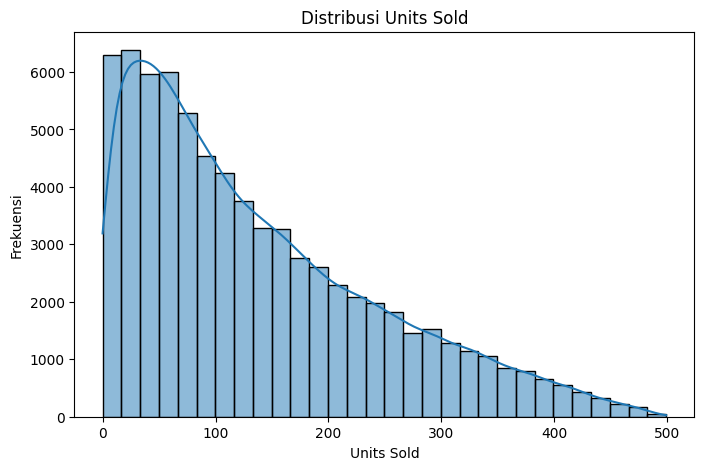

In [14]:
# Distribusi Units Sold 
print("="*60) 
print("VISUALISASI DISTRIBUSI UNITS SOLD") 
print("="*60) 
plt.figure(figsize=(8,5)) 
sns.histplot(df['Units Sold'], bins=30, kde=True) 
plt.title("Distribusi Units Sold") 
plt.xlabel("Units Sold") 
plt.ylabel("Frekuensi") 
plt.show()

VISUALISASI TOTAL UNITS SOLD BERDASARKAN KATEGORI


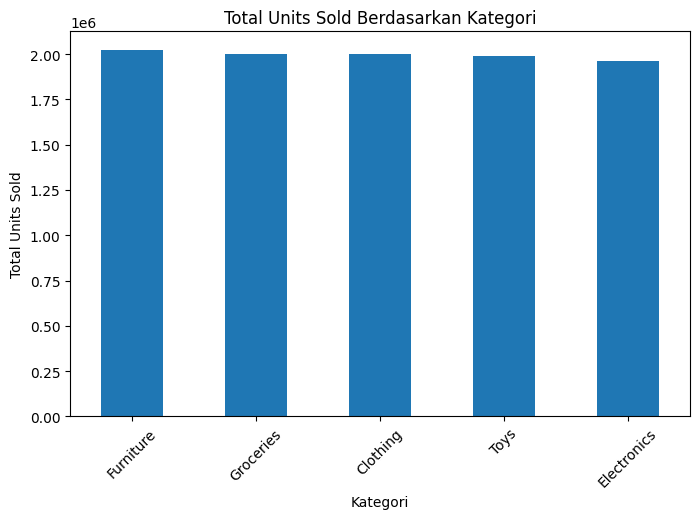

In [15]:
# Total Units Sold berdasarkan Category
print("="*60)
print("VISUALISASI TOTAL UNITS SOLD BERDASARKAN KATEGORI")
print("="*60)

category_sales = df.groupby('Category')['Units Sold'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')
plt.title("Total Units Sold Berdasarkan Kategori")
plt.xlabel("Kategori")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45)
plt.show()

VISUALISASI TOTAL UNITS SOLD BERDASARKAN REGION


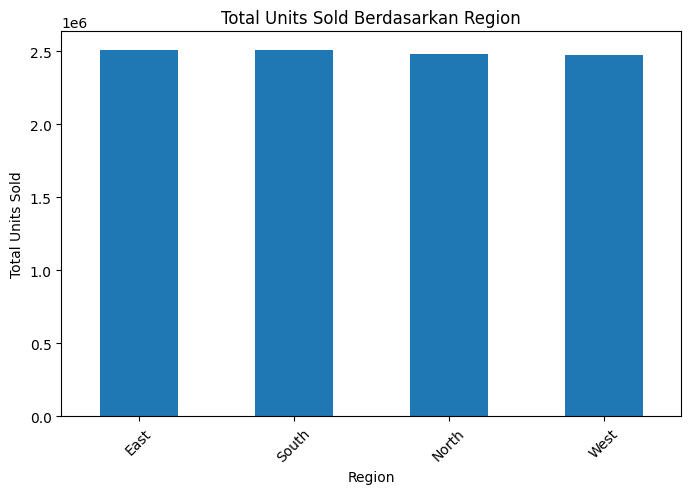

In [16]:
# Total Units Sold berdasarkan Region 
print("="*60) 
print("VISUALISASI TOTAL UNITS SOLD BERDASARKAN REGION") 
print("="*60) 
region_sales = df.groupby('Region')['Units Sold'].sum().sort_values(ascending=False) 
plt.figure(figsize=(8,5)) 
region_sales.plot(kind='bar') 
plt.title("Total Units Sold Berdasarkan Region") 
plt.xlabel("Region") 
plt.ylabel("Total Units Sold") 
plt.xticks(rotation=45) 
plt.show()

VISUALISASI TOTAL UNITS SOLD BERDASARKAN MUSIM


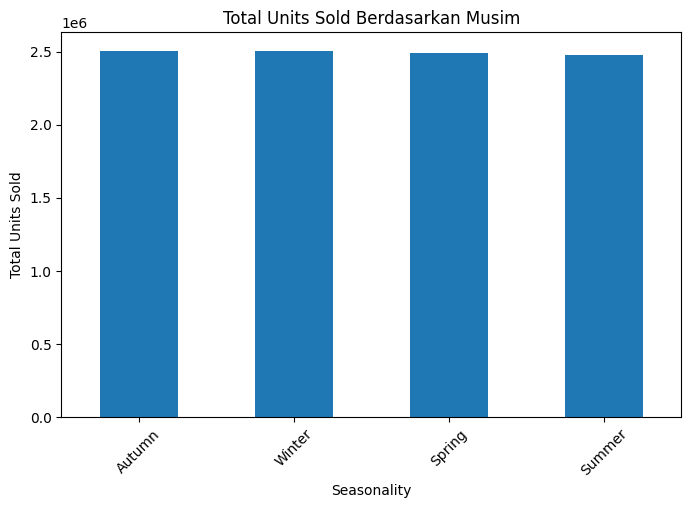

In [17]:
# Total Units Sold berdasarkan Seasonality 
print("="*60) 
print("VISUALISASI TOTAL UNITS SOLD BERDASARKAN MUSIM") 
print("="*60) 
season_sales = df.groupby('Seasonality')['Units Sold'].sum().sort_values(ascending=False) 
plt.figure(figsize=(8,5)) 
season_sales.plot(kind='bar') 
plt.title("Total Units Sold Berdasarkan Musim") 
plt.xlabel("Seasonality") 
plt.ylabel("Total Units Sold") 
plt.xticks(rotation=45) 
plt.show()

VISUALISASI RATA-RATA UNITS SOLD BERDASARKAN PROMOSI/LIBUR


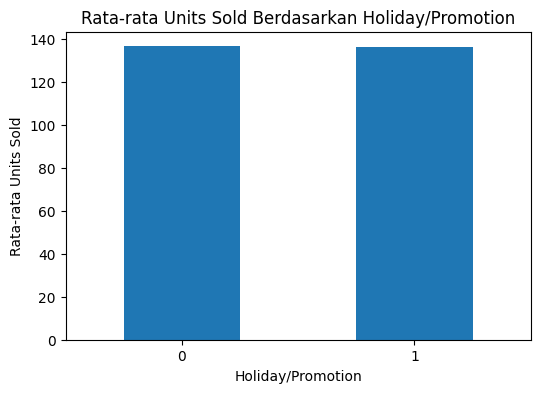

In [18]:
# Rata-rata Units Sold berdasarkan Holiday/Promotion 
print("="*60) 
print("VISUALISASI RATA-RATA UNITS SOLD BERDASARKAN PROMOSI/LIBUR") 
print("="*60) 
promo_sales = df.groupby('Holiday/Promotion')['Units Sold'].mean() 
plt.figure(figsize=(6,4)) 
promo_sales.plot(kind='bar') 
plt.title("Rata-rata Units Sold Berdasarkan Holiday/Promotion") 
plt.xlabel("Holiday/Promotion") 
plt.ylabel("Rata-rata Units Sold") 
plt.xticks(rotation=0) 
plt.show()

VISUALISASI TREN TOTAL UNITS SOLD DARI WAKTU KE WAKTU


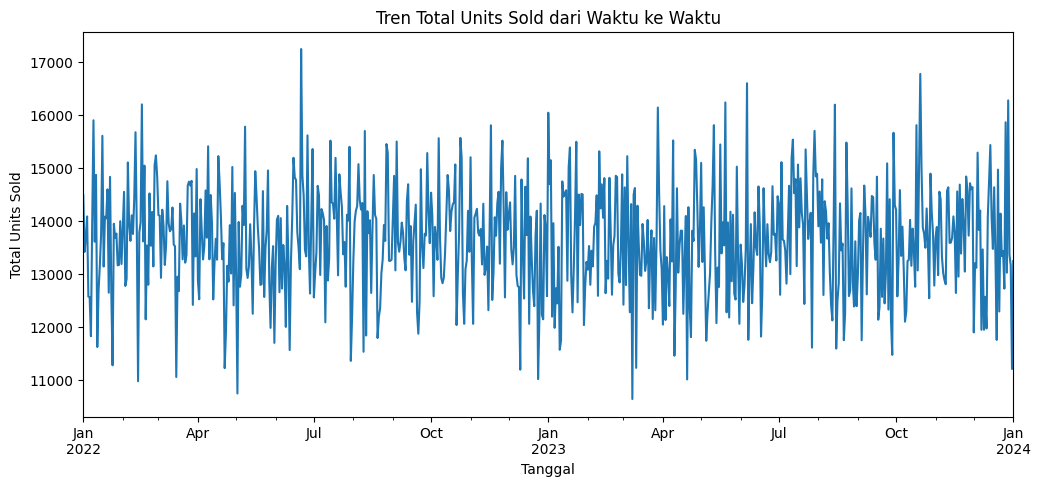

In [19]:
# Tren total Units Sold berdasarkan tanggal 
print("="*60) 
print("VISUALISASI TREN TOTAL UNITS SOLD DARI WAKTU KE WAKTU") 
print("="*60) 
daily_sales = df.groupby('Date')['Units Sold'].sum() 
plt.figure(figsize=(12,5)) 
daily_sales.plot() 
plt.title("Tren Total Units Sold dari Waktu ke Waktu") 
plt.xlabel("Tanggal") 
plt.ylabel("Total Units Sold") 
plt.show()

VISUALISASI KORELASI ANTAR VARIABEL NUMERIK


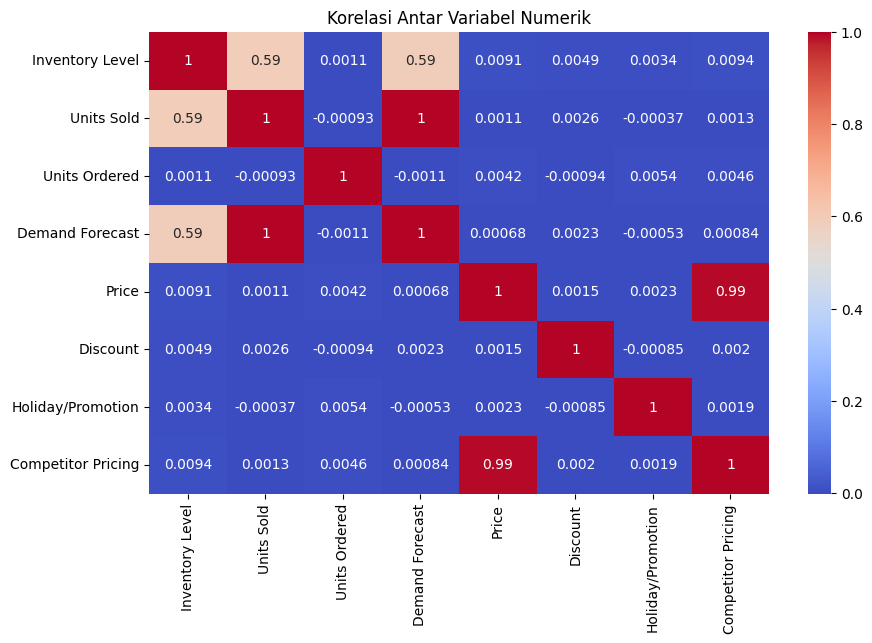

In [20]:
# Korelasi antar variabel numerik 
print("="*60) 
print("VISUALISASI KORELASI ANTAR VARIABEL NUMERIK") 
print("="*60) 
plt.figure(figsize=(10,6)) 
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm') 
plt.title("Korelasi Antar Variabel Numerik") 
plt.show()

### Kesimpulan Data Understanding 
Berdasarkan hasil Data Understanding, dataset **retail_store_inventory.csv** memiliki data penjualan dan persediaan produk retail yang dapat digunakan untuk analisis forecasting. Kolom **Date** digunakan sebagai variabel waktu, sedangkan kolom **Units Sold** digunakan sebagai variabel target yang akan diramalkan. Selain itu, terdapat beberapa variabel pendukung seperti **Category, Region, Inventory Level, Price, Discount, Holiday/Promotion, Weather Condition, Competitor Pricing,** dan **Seasonality** yang dapat digunakan untuk memahami faktor-faktor yang berhubungan dengan jumlah produk yang terjual.

## Fase 3: Data Preparation

Pada fase Data Preparation, dilakukan proses persiapan data sebelum masuk ke tahap modeling. Tahapan ini bertujuan agar data yang digunakan sudah bersih, sesuai, dan siap diproses menggunakan metode Linear Regression.

Berdasarkan hasil Data Understanding, dataset tidak memiliki missing value dan data duplikat. Oleh karena itu, proses data cleaning dan handling missing values dilakukan sebagai validasi untuk memastikan bahwa data sudah siap digunakan.

Tahapan yang dilakukan pada fase ini meliputi data cleaning, handling missing values, transformasi data, encoding data kategorikal, normalisasi data, serta pembagian data training dan testing.

### A. Data Cleaning

Data cleaning dilakukan untuk memastikan dataset dalam kondisi bersih sebelum digunakan pada tahap modeling. Pada tahap ini dilakukan pengecekan data duplikat. Jika terdapat data duplikat, maka data tersebut akan dihapus. Namun, jika tidak terdapat data duplikat, maka dataset dapat langsung digunakan ke tahap berikutnya.

In [21]:
# Membuat salinan dataset agar data asli tetap aman
df_clean = df.copy()

print("="*60)
print("DATA CLEANING")
print("="*60)

duplicate_count = df_clean.duplicated().sum()
print("Jumlah data duplikat:", duplicate_count)

if duplicate_count == 0:
    print("Tidak terdapat data duplikat, sehingga tidak perlu dilakukan penghapusan.")
else:
    df_clean = df_clean.drop_duplicates()
    print("Data duplikat berhasil dihapus.")

print("Ukuran data setelah data cleaning:", df_clean.shape)

DATA CLEANING
Jumlah data duplikat: 0
Tidak terdapat data duplikat, sehingga tidak perlu dilakukan penghapusan.
Ukuran data setelah data cleaning: (73100, 15)


### B. Handling Missing Values

Handling missing values dilakukan untuk mengecek apakah terdapat data kosong pada dataset. Berdasarkan hasil pengecekan, dataset tidak memiliki missing value. Oleh karena itu, tidak diperlukan proses imputasi atau pengisian data kosong.

In [22]:
print("="*60)
print("HANDLING MISSING VALUES")
print("="*60)

total_missing = df_clean.isnull().sum().sum()
print("Total missing value:", total_missing)

if total_missing == 0:
    print("Tidak terdapat missing value, sehingga tidak perlu dilakukan imputasi data.")
else:
    numeric_columns = df_clean.select_dtypes(include=['int64', 'float64']).columns
    categorical_columns = df_clean.select_dtypes(include=['object']).columns

    for col in numeric_columns:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

    for col in categorical_columns:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

    print("Missing value berhasil ditangani.")

HANDLING MISSING VALUES
Total missing value: 0
Tidak terdapat missing value, sehingga tidak perlu dilakukan imputasi data.


### C. Transformasi Kolom Date

Kolom Date diubah menjadi tipe data datetime agar dapat digunakan sebagai informasi waktu. Setelah itu, dibuat beberapa fitur baru seperti Year, Month, Day, dan DayOfWeek. Fitur waktu ini digunakan untuk membantu model memahami pola penjualan berdasarkan waktu.

In [23]:
print("="*60)
print("TRANSFORMASI KOLOM DATE")
print("="*60)

df_clean['Date'] = pd.to_datetime(df_clean['Date'])

df_clean['Year'] = df_clean['Date'].dt.year
df_clean['Month'] = df_clean['Date'].dt.month
df_clean['Day'] = df_clean['Date'].dt.day
df_clean['DayOfWeek'] = df_clean['Date'].dt.dayofweek

print("Kolom Date berhasil diubah menjadi tipe datetime.")
print("Fitur waktu baru berhasil dibuat: Year, Month, Day, DayOfWeek")

TRANSFORMASI KOLOM DATE
Kolom Date berhasil diubah menjadi tipe datetime.
Fitur waktu baru berhasil dibuat: Year, Month, Day, DayOfWeek


In [24]:
df_clean[['Date', 'Year', 'Month', 'Day', 'DayOfWeek']].head()

,Date,Year,Month,Day,DayOfWeek
0,2022-01-01,2022,1,1,5
1,2022-01-01,2022,1,1,5
2,2022-01-01,2022,1,1,5
3,2022-01-01,2022,1,1,5
4,2022-01-01,2022,1,1,5


### D. Encoding Data Kategorikal

Metode Linear Regression hanya dapat memproses data dalam bentuk numerik. Oleh karena itu, data kategorikal perlu diubah menjadi bentuk angka. Pada tahap ini, encoding dilakukan pada kolom Store ID, Product ID, Category, Region, Weather Condition, dan Seasonality.

In [25]:
from sklearn.preprocessing import LabelEncoder

print("="*60)
print("ENCODING DATA KATEGORIKAL")
print("="*60)

categorical_features = [
    'Store ID',
    'Product ID',
    'Category',
    'Region',
    'Weather Condition',
    'Seasonality'
]

if df_clean['Holiday/Promotion'].dtype == 'object':
    categorical_features.append('Holiday/Promotion')

label_encoders = {}

for col in categorical_features:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    label_encoders[col] = le
    print(f"Kolom '{col}' berhasil diencoding.")

print("\nEncoding data kategorikal selesai.")

ENCODING DATA KATEGORIKAL
Kolom 'Store ID' berhasil diencoding.
Kolom 'Product ID' berhasil diencoding.
Kolom 'Category' berhasil diencoding.
Kolom 'Region' berhasil diencoding.
Kolom 'Weather Condition' berhasil diencoding.
Kolom 'Seasonality' berhasil diencoding.

Encoding data kategorikal selesai.


In [26]:
print("="*60)
print("TIPE DATA SETELAH ENCODING")
print("="*60)

df_clean.dtypes

TIPE DATA SETELAH ENCODING


Date                  datetime64[ns]
Store ID                       int64
Product ID                     int64
Category                       int64
Region                         int64
Inventory Level                int64
Units Sold                     int64
Units Ordered                  int64
Demand Forecast              float64
Price                        float64
Discount                       int64
Weather Condition              int64
Holiday/Promotion              int64
Competitor Pricing           float64
Seasonality                    int64
Year                           int32
Month                          int32
Day                            int32
DayOfWeek                      int32
dtype: object

### E. Menentukan Fitur dan Target

Pada project ini, variabel target yang akan diramalkan adalah Units Sold. Fitur yang digunakan terdiri dari variabel pendukung seperti Store ID, Product ID, Category, Region, Inventory Level, Units Ordered, Demand Forecast, Price, Discount, Weather Condition, Holiday/Promotion, Competitor Pricing, Seasonality, dan fitur waktu.

In [27]:
print("="*60)
print("MENENTUKAN FITUR DAN TARGET")
print("="*60)

features = [
    'Store ID',
    'Product ID',
    'Category',
    'Region',
    'Inventory Level',
    'Units Ordered',
    'Demand Forecast',
    'Price',
    'Discount',
    'Weather Condition',
    'Holiday/Promotion',
    'Competitor Pricing',
    'Seasonality',
    'Year',
    'Month',
    'Day',
    'DayOfWeek'
]

target = 'Units Sold'

X = df_clean[features]
y = df_clean[target]

print("Target yang diramalkan:", target)
print("Jumlah fitur:", len(features))
print("Ukuran X:", X.shape)
print("Ukuran y:", y.shape)

MENENTUKAN FITUR DAN TARGET
Target yang diramalkan: Units Sold
Jumlah fitur: 17
Ukuran X: (73100, 17)
Ukuran y: (73100,)


In [28]:
print("Daftar fitur yang digunakan:")

for i, col in enumerate(features, start=1):
    print(f"{i}. {col}")

Daftar fitur yang digunakan:
1. Store ID
2. Product ID
3. Category
4. Region
5. Inventory Level
6. Units Ordered
7. Demand Forecast
8. Price
9. Discount
10. Weather Condition
11. Holiday/Promotion
12. Competitor Pricing
13. Seasonality
14. Year
15. Month
16. Day
17. DayOfWeek


### F. Pembagian Data Training dan Testing

Dataset dibagi menjadi data training dan data testing. Data training digunakan untuk melatih model, sedangkan data testing digunakan untuk menguji performa model.

In [29]:
from sklearn.model_selection import train_test_split

print("="*60)
print("PEMBAGIAN DATA TRAINING DAN TESTING")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Data berhasil dibagi menjadi training dan testing.")
print("Jumlah data training:", X_train.shape[0])
print("Jumlah data testing:", X_test.shape[0])
print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test:", X_test.shape)
print("Ukuran y_train:", y_train.shape)
print("Ukuran y_test:", y_test.shape)

PEMBAGIAN DATA TRAINING DAN TESTING
Data berhasil dibagi menjadi training dan testing.
Jumlah data training: 58480
Jumlah data testing: 14620
Ukuran X_train: (58480, 17)
Ukuran X_test: (14620, 17)
Ukuran y_train: (58480,)
Ukuran y_test: (14620,)


### G. Normalisasi Data

Normalisasi dilakukan agar setiap fitur memiliki skala yang lebih seimbang. Pada project ini digunakan StandardScaler untuk menstandarkan data sebelum digunakan pada model Linear Regression.

In [30]:
print("="*60)
print("NORMALISASI DATA")
print("="*60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Normalisasi data berhasil dilakukan menggunakan StandardScaler.")
print("Ukuran data training setelah normalisasi:", X_train_scaled.shape)
print("Ukuran data testing setelah normalisasi:", X_test_scaled.shape)

NORMALISASI DATA
Normalisasi data berhasil dilakukan menggunakan StandardScaler.
Ukuran data training setelah normalisasi: (58480, 17)
Ukuran data testing setelah normalisasi: (14620, 17)


### Kesimpulan Data Preparation

Berdasarkan hasil Data Preparation, dataset sudah dalam kondisi bersih karena tidak memiliki missing value dan data duplikat. Selanjutnya, kolom Date telah ditransformasikan menjadi fitur waktu, data kategorikal telah diubah menjadi bentuk numerik melalui encoding, fitur dan target telah ditentukan, serta data telah dinormalisasi dan dibagi menjadi data training dan testing.

Dengan demikian, dataset sudah siap digunakan pada fase berikutnya, yaitu Modeling menggunakan metode Linear Regression.

## Fase 4: Modeling

Pada fase Modeling, dilakukan penerapan algoritma sesuai dengan studi kasus yang telah ditentukan. Project ini menggunakan algoritma **Linear Regression** untuk melakukan forecasting atau peramalan jumlah produk yang terjual, yaitu **Units Sold**.

Linear Regression digunakan karena model ini dapat memprediksi nilai numerik berdasarkan hubungan antara variabel target dan variabel pendukung. Dalam project ini, variabel target yang diramalkan adalah **Units Sold**, sedangkan variabel pendukung yang digunakan antara lain stok barang, jumlah pesanan, demand forecast, harga, diskon, promosi, cuaca, musim, wilayah, kategori produk, dan fitur waktu.

Data yang telah dipersiapkan pada fase sebelumnya dibagi menjadi data training dan data testing. Data training digunakan untuk melatih model, sedangkan data testing digunakan untuk menguji kemampuan model dalam memprediksi data baru.

### A. Membuat Model Linear Regression

Setelah algoritma diimport, langkah berikutnya adalah membuat objek model Linear Regression. Model ini akan digunakan untuk mempelajari pola hubungan antara fitur input dan target Units Sold.

In [31]:
# Membuat model Linear Regression
model_lr = LinearRegression()

print("="*60)
print("MEMBUAT MODEL LINEAR REGRESSION")
print("="*60)
print("Model Linear Regression berhasil dibuat.")

MEMBUAT MODEL LINEAR REGRESSION
Model Linear Regression berhasil dibuat.


### B. Training Model

Training model dilakukan menggunakan data training yang telah dibuat pada fase Data Preparation. Pada tahap ini, model mempelajari hubungan antara fitur-fitur pendukung dengan target **Units Sold**.

In [32]:
print("="*60)
print("TRAINING MODEL")
print("="*60)

# Melatih model menggunakan data training yang sudah dinormalisasi
model_lr.fit(X_train_scaled, y_train)

print("Proses training model Linear Regression berhasil dilakukan.")
print("Jumlah data training:", X_train_scaled.shape[0])
print("Jumlah fitur yang digunakan:", X_train_scaled.shape[1])

TRAINING MODEL
Proses training model Linear Regression berhasil dilakukan.
Jumlah data training: 58480
Jumlah fitur yang digunakan: 17


### C. Testing Model

Setelah model dilatih, tahap berikutnya adalah melakukan testing menggunakan data testing. Data testing digunakan untuk mengetahui bagaimana model memprediksi jumlah produk terjual pada data yang belum pernah dipelajari sebelumnya.

In [33]:
print("="*60)
print("TESTING MODEL")
print("="*60)

# Melakukan prediksi pada data testing yang sudah dinormalisasi
y_pred = model_lr.predict(X_test_scaled)

print("Proses testing model berhasil dilakukan.")
print("Jumlah data testing:", X_test_scaled.shape[0])
print("Jumlah hasil prediksi:", len(y_pred))

TESTING MODEL
Proses testing model berhasil dilakukan.
Jumlah data testing: 14620
Jumlah hasil prediksi: 14620


### D. Menampilkan Hasil Prediksi Awal

Pada tahap ini ditampilkan perbandingan antara nilai aktual **Units Sold** dan hasil prediksi dari model Linear Regression. Perbandingan ini digunakan untuk melihat gambaran awal hasil peramalan model.

In [34]:
# Membuat dataframe perbandingan hasil aktual dan prediksi
hasil_prediksi = pd.DataFrame({
    'Actual Units Sold': y_test.values,
    'Predicted Units Sold': y_pred
})

print("="*60)
print("HASIL PREDIKSI AWAL")
print("="*60)

hasil_prediksi.head(10)

HASIL PREDIKSI AWAL


,Actual Units Sold,Predicted Units Sold
0,138,134.069329
1,105,112.382197
2,70,73.375212
3,105,98.752753
4,76,87.214403
5,206,217.000199
6,87,85.935557
7,53,53.140760
8,129,133.572991
9,55,41.594093


### F. Membulatkan Hasil Prediksi

Karena Units Sold merupakan jumlah unit produk yang terjual, maka hasil prediksi dapat dibulatkan agar lebih mudah dibaca. Namun, nilai asli hasil prediksi tetap digunakan untuk proses evaluasi model.

In [35]:
# Menambahkan kolom hasil prediksi yang dibulatkan
hasil_prediksi['Predicted Units Sold Rounded'] = hasil_prediksi['Predicted Units Sold'].round()

print("="*60)
print("HASIL PREDIKSI SETELAH DIBULATKAN")
print("="*60)

hasil_prediksi.head(10)

HASIL PREDIKSI SETELAH DIBULATKAN


,Actual Units Sold,Predicted Units Sold,Predicted Units Sold Rounded
0,138,134.069329,134.0
1,105,112.382197,112.0
2,70,73.375212,73.0
3,105,98.752753,99.0
4,76,87.214403,87.0
5,206,217.000199,217.0
6,87,85.935557,86.0
7,53,53.140760,53.0
8,129,133.572991,134.0
9,55,41.594093,42.0


### G. Menampilkan Koefisien Model

Koefisien pada Linear Regression menunjukkan seberapa besar pengaruh masing-masing fitur terhadap target **Units Sold**. Nilai koefisien positif menunjukkan hubungan searah, sedangkan nilai koefisien negatif menunjukkan hubungan berlawanan arah.

In [36]:
# Menampilkan koefisien setiap fitur
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model_lr.coef_
})

coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

print("="*60)
print("KOEFISIEN MODEL LINEAR REGRESSION")
print("="*60)

coef_df

KOEFISIEN MODEL LINEAR REGRESSION


,Feature,Coefficient
6,Demand Forecast,108.300243
4,Inventory Level,0.509494
11,Competitor Pricing,0.129563
5,Units Ordered,0.033515
1,Product ID,0.033235
10,Holiday/Promotion,0.026800
15,Day,0.020135
2,Category,0.007434
0,Store ID,0.001783
8,Discount,0.001564


### H. Visualisasi Perbandingan Aktual dan Prediksi

Visualisasi dilakukan untuk melihat perbandingan antara nilai aktual dan nilai prediksi. Grafik ini memberikan gambaran awal apakah hasil prediksi model mendekati nilai sebenarnya atau tidak.

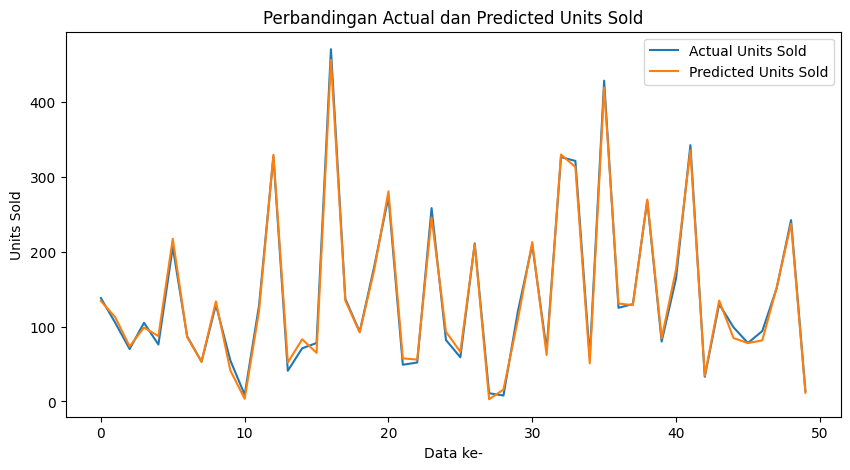

In [37]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:50], label='Actual Units Sold')
plt.plot(y_pred[:50], label='Predicted Units Sold')
plt.title("Perbandingan Actual dan Predicted Units Sold")
plt.xlabel("Data ke-")
plt.ylabel("Units Sold")
plt.legend()
plt.show()

### Kesimpulan Modeling

Pada fase Modeling, algoritma **Linear Regression** telah berhasil diterapkan untuk melakukan peramalan jumlah produk terjual atau **Units Sold**. Model dilatih menggunakan data training dan diuji menggunakan data testing.

Hasil dari tahap modeling berupa nilai prediksi **Units Sold** yang kemudian dibandingkan dengan nilai aktual. Selanjutnya, hasil model akan dievaluasi pada fase Evaluation untuk mengetahui tingkat kesalahan prediksi menggunakan metrik evaluasi seperti MAE, MSE, RMSE, dan R² Score.

## Fase 5: Evaluation

Pada fase Evaluation, dilakukan evaluasi terhadap model yang telah dibuat pada tahap Modeling. Evaluasi ini bertujuan untuk mengetahui seberapa baik model Linear Regression dalam melakukan peramalan jumlah produk terjual atau Units Sold.

Evaluasi dilakukan dengan membandingkan nilai aktual dan nilai prediksi menggunakan beberapa metrik evaluasi, yaitu Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), dan R² Score.

### A. Menghitung Nilai Evaluasi Model

Nilai evaluasi dihitung dengan membandingkan data aktual pada y_test dengan hasil prediksi model pada y_pred. Semakin kecil nilai MAE, MSE, dan RMSE, maka semakin kecil tingkat kesalahan prediksi. Sedangkan semakin mendekati 1 nilai R² Score, maka performa model semakin baik.

In [38]:
print("="*60)
print("MENGHITUNG EVALUASI MODEL")
print("="*60)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

MENGHITUNG EVALUASI MODEL
Mean Absolute Error (MAE): 7.418666688718108
Mean Squared Error (MSE): 73.97987463751355
Root Mean Squared Error (RMSE): 8.601155424564396
R² Score: 0.9937515227357155


### B. Menampilkan Hasil Evaluasi dalam Tabel

Hasil evaluasi model ditampilkan dalam bentuk tabel agar lebih mudah dibaca dan dianalisis.

In [39]:
evaluation_result = pd.DataFrame({
    'Metrik Evaluasi': ['MAE', 'MSE', 'RMSE', 'R² Score'],
    'Nilai': [mae, mse, rmse, r2]
})

print("="*60)
print("HASIL EVALUASI MODEL")
print("="*60)

evaluation_result

HASIL EVALUASI MODEL


,Metrik Evaluasi,Nilai
0,MAE,7.418667
1,MSE,73.979875
2,RMSE,8.601155
3,R² Score,0.993752


### C. Interpretasi Performa Model

Interpretasi dilakukan untuk mengetahui tingkat performa model berdasarkan hasil evaluasi. Pada model regresi, nilai error yang kecil menunjukkan bahwa hasil prediksi mendekati nilai aktual. Sementara itu, nilai R² Score digunakan untuk melihat kemampuan model dalam menjelaskan variasi data target.

In [40]:
print("="*60)
print("INTERPRETASI PERFORMA MODEL")
print("="*60)

print(f"MAE sebesar {mae:.2f} menunjukkan rata-rata kesalahan prediksi model sekitar {mae:.2f} unit.")
print(f"RMSE sebesar {rmse:.2f} menunjukkan tingkat kesalahan prediksi dengan mempertimbangkan error yang lebih besar.")
print(f"R² Score sebesar {r2:.4f} menunjukkan kemampuan model dalam menjelaskan variasi data target.")

if r2 >= 0.80:
    print("Performa model tergolong sangat baik.")
elif r2 >= 0.60:
    print("Performa model tergolong cukup baik.")
elif r2 >= 0.40:
    print("Performa model tergolong sedang.")
else:
    print("Performa model masih kurang baik dan perlu ditingkatkan.")

INTERPRETASI PERFORMA MODEL
MAE sebesar 7.42 menunjukkan rata-rata kesalahan prediksi model sekitar 7.42 unit.
RMSE sebesar 8.60 menunjukkan tingkat kesalahan prediksi dengan mempertimbangkan error yang lebih besar.
R² Score sebesar 0.9938 menunjukkan kemampuan model dalam menjelaskan variasi data target.
Performa model tergolong sangat baik.


### D. Visualisasi Aktual vs Prediksi

Visualisasi dilakukan untuk membandingkan nilai aktual Units Sold dengan nilai hasil prediksi model. Jika titik-titik data berada mendekati garis diagonal, maka hasil prediksi model semakin mendekati nilai aktual.

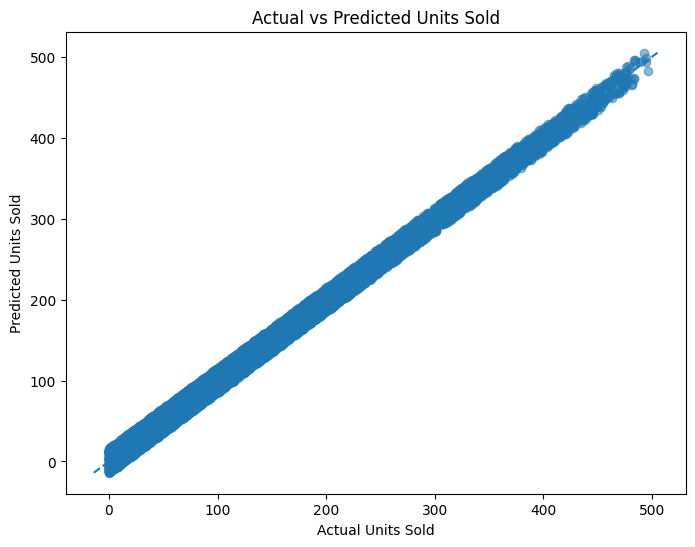

In [41]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Units Sold")
plt.ylabel("Predicted Units Sold")
plt.title("Actual vs Predicted Units Sold")

# Garis diagonal sebagai acuan prediksi ideal
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle='--')

plt.show()

### E. Visualisasi Error Prediksi

Visualisasi error dilakukan untuk melihat selisih antara nilai aktual dan nilai prediksi. Error yang menyebar secara acak dan tidak terlalu besar menunjukkan bahwa model memiliki performa prediksi yang cukup baik.

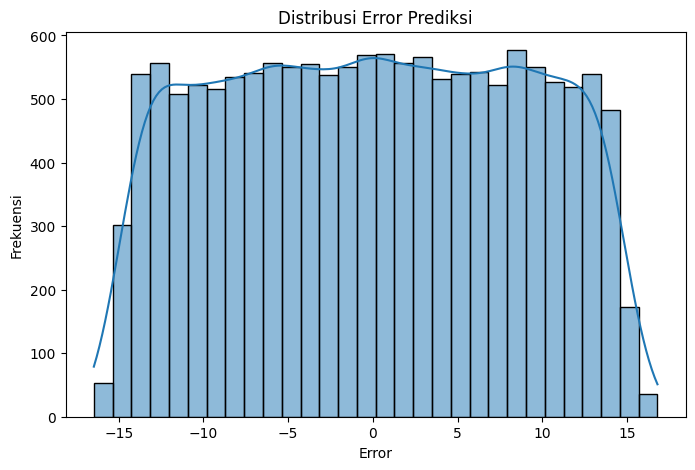

In [42]:
error = y_test - y_pred

plt.figure(figsize=(8,5))
sns.histplot(error, bins=30, kde=True)
plt.title("Distribusi Error Prediksi")
plt.xlabel("Error")
plt.ylabel("Frekuensi")
plt.show()

### G. Kesimpulan Evaluation

Berdasarkan hasil evaluasi, model **Linear Regression** menunjukkan performa yang sangat baik dalam meramalkan jumlah produk terjual atau **Units Sold** pada dataset **Retail Store Inventory**.

Nilai **MAE sebesar 7.42** menunjukkan bahwa rata-rata kesalahan prediksi model adalah sekitar **7 unit produk**. Nilai **RMSE sebesar 8.60** menunjukkan bahwa tingkat kesalahan prediksi masih tergolong rendah dan tidak terlalu jauh dari nilai MAE, sehingga error model dapat dikatakan cukup stabil.

Selain itu, nilai **R² Score sebesar 0.9938** menunjukkan bahwa model mampu menjelaskan sekitar **99,38% variasi data Units Sold** berdasarkan fitur-fitur yang digunakan. Nilai R² yang mendekati 1 menandakan bahwa model memiliki kemampuan prediksi yang sangat baik. Nilai R² yang sangat tinggi kemungkinan dipengaruhi oleh adanya fitur yang memiliki hubungan kuat dengan target **Units Sold**, seperti **Demand Forecast**, **Inventory Level**, dan **Units Ordered**. Oleh karena itu, meskipun hasil model sangat baik, evaluasi tetap perlu diperhatikan agar model tidak hanya bekerja baik pada dataset ini, tetapi juga dapat digunakan pada data retail lain.

Dengan demikian, model **Linear Regression** dapat dikatakan sangat baik dalam melakukan forecasting jumlah produk terjual. Hasil peramalan ini dapat membantu pihak retail dalam memperkirakan kebutuhan stok barang, mengurangi risiko kehabisan stok, menghindari penumpukan barang, serta mendukung pengambilan keputusan dalam strategi penjualan dan persediaan.